### **The Simplest Graph**

![simple router graph.png](<attachment:simple router graph.png>)
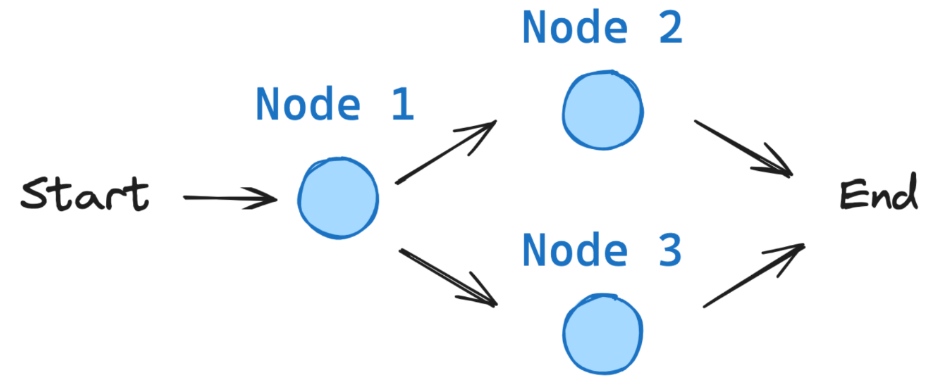

In [ ]:
%%capture --no-stderr # Captures and suppresses all standard output from the cell while allowing error messages (\texttt{stderr}) to be displayed
%pip install --quiet -U langgraph # Installs the langgraph package with minimal console output

#### **State**
State of the graph refers to the information or data that is being tracked and updated as you move through each step (node) of the graph.

State schema serves as the input schema for all Nodes and Edges in the graph.

In [2]:
# Imports TypedDict from the typing_extensions package
# `TypedDict` lets us define a dictionary with fixed keys and value types
from typing_extensions import TypedDict

# Defines a new type called State using TypedDict
# State is a dictionary that requires a string value graph_state key
class State(TypedDict):
    graph_state: str

#### **Nodes**
A node is a Python function that processes the current state and returns the updated state. By default, the new value returned by each node will override the prior state value.

In [3]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] + " I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] + " happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] + " sad!"}

#### **Edges**
Edges connect the nodes.

Normal Edges are used if you want to always go from.

Conditional Edges are used if you want to optionally route between nodes. Conditional edges are implemented as functions that return the next node to visit based upon some logic.

In [4]:
import random
# `Literal` specifies function can only return..
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

#### **Graph Construction**

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

#### **Graph Invocation**

In [ ]:
graph.invoke({"graph_state" : "Hi, this is Khoa."})